# Load modules

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import os
import numpy as np
from shapely.geometry import Polygon


In [3]:
rc = lambda r,c:pl.Config(set_tbl_rows=r,set_tbl_cols=c)

In [4]:
project_name='240430 45 50 55c'
if not os.path.exists('plots/'+project_name):
    os.mkdir('plots/'+project_name)
if not os.path.exists('Processed data/'+project_name):
    os.mkdir('Processed data/'+project_name)
if not os.path.exists('Raw data/'+project_name):
    os.mkdir('Raw data/'+project_name)

# Load data

## Batch files

In [5]:
def read_batch_file(path):
    start = pl.read_csv(path).with_row_index().filter(pl.col('[Header]')=='[Batch Table]')['index'][0]+2
    nrows = int(pl.read_csv(path,
                skip_rows=start,has_header=False,n_rows=1)[0,0].split('\t')[-1])
    return pl.read_csv(path,
                skip_rows=start+1,has_header=True,n_rows=nrows,separator='\t')

In [6]:
b0 = read_batch_file('Processed data/batch files/240428-std curve.txt')
b1 = read_batch_file('Processed data/batch files/240430 solABm1-42.txt')
b2 = read_batch_file('Processed data/batch files/240502 solABm1-42 t2 55deg.txt')

batch = pl.concat([b0,b1,b2])
batch

Run Mode,Tray Name,Vial#,Sample Name,Sample ID,Sample Type,Analysis Type,Method File,Data File,Background,Background Data File,Level#,Inj. Volume,ISTD Amt.,Sample Amt.,Dil. Factor,System Check,Report Output,Report Format File,User Prog.,Action,Data Comment,AutoPurge,Baseline Check,Option 1,Option 2,Option 3,Option 4,Option 5,Custom Parameters,Auto Tuning,Tuning File,PsiPort Instrument Method File,Summary Type,Summary Report Format File,Option 6,Option 7,Option 8,Option 9,Option 10,System Suitability,Multi Injection,Barcode,Sampler File,Conc. Overrides
str,str,str,str,i64,str,str,str,str,i64,str,i64,f64,str,i64,i64,str,i64,str,str,str,str,i64,i64,str,str,str,str,str,str,i64,str,str,i64,str,str,str,str,str,str,i64,i64,str,str,str
"""DL AQ DP""","""1""","""-1""","""none""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_none_001_01.l…",0,null,0,10.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""A2""","""buffer""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_buffer_001_02…",0,null,0,30.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""B2""","""0.11pmol ABm1-42""",1,"""1:Standard:(I)""",null,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_0.11pmol ABm1…",0,null,1,3.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""B2""","""0.11pmol ABm1-42""",1,"""1:Standard""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_0.11pmol ABm1…",0,null,1,3.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""B2""","""0.33pmol ABm1-42""",1,"""1:Standard""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_0.33pmol ABm1…",0,null,2,9.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""DL AQ DP""","""1""","""-1""","""none""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240502 solABm1-42 t2 55deg_non…",0,null,0,10.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""F3""","""ABm1-42 55deg 3.5 days""",2,"""0:Unknown""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240502 solABm1-42 t2 55deg_ABm…",0,null,0,30.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""F4""","""ABm1-42 55deg 3.5 days""",3,"""0:Unknown""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240502 solABm1-42 t2 55deg_ABm…",0,null,0,30.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null


In [7]:
batch=batch.rename({'Data File':'Data Filename'})

## UV

In [8]:
summary205 = pl.read_csv('Processed data/'+project_name+'/UV quant table.txt',
                         skip_rows=2,separator='\t',null_values='-----').drop_nulls('Sample Type')
summary205

,Data Filename,Sample Type,Sample Name,Vial#,Ret. Time,Area,Conc.,Height,Std. Conc.,Accuracy[%],Cal. Point,Peak Start,Peak End,Quant. Limit(QL),S/N,Tailing F.
i64,str,str,str,str,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,str
1,"""240428-std curve_0.11pmol ABm1…","""Standard(Calc.Point)""","""0.11pmol ABm1-42""","""B2""",4.395,1872.0,0.079,1227.0,0.11,72.1,"""*""",4.362,4.445,0.03,29.01,"""1.099"""
2,"""240428-std curve_0.11pmol ABm1…","""Standard(Calc.Point)""","""0.11pmol ABm1-42""","""B2""",4.397,2086.0,0.088,1277.0,0.11,79.8,"""*""",4.347,4.435,0.04,24.76,"""1.176"""
3,"""240428-std curve_0.33pmol ABm1…","""Standard(Calc.Point)""","""0.33pmol ABm1-42""","""B2""",4.412,9363.0,0.375,4412.0,0.33,113.6,"""*""",4.357,4.545,0.04,93.19,"""1.737"""
4,"""240428-std curve_0.33pmol ABm1…","""Standard(Calc.Point)""","""0.33pmol ABm1-42""","""B2""",4.407,9840.0,0.394,4726.0,0.33,119.3,"""*""",4.33,4.488,0.04,112.1,"""1.024"""
5,"""240428-std curve_1pmol ABm1-42…","""Standard(Calc.Point)""","""1pmol ABm1-42""","""B2""",4.41,26119.0,1.036,13193.0,1.0,103.6,"""*""",4.34,4.492,0.04,275.81,"""0.964"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
26,"""240502 solABm1-42 t2 55deg_ABm…","""Unknown""","""ABm1-42 55deg 3.5 days""","""F3""",4.402,88748.0,3.506,28671.0,null,null,null,4.15,4.637,0.07,506.36,"""1.806"""
27,"""240502 solABm1-42 t2 55deg_ABm…","""Unknown""","""ABm1-42 55deg 3.5 days""","""F4""",4.408,97874.0,3.866,32534.0,null,null,null,4.15,4.607,0.06,658.98,"""1.772"""
28,"""240502 solABm1-42 t2 55deg_ABm…","""Unknown""","""ABm1-42 55deg 3.5 days""","""F5""",4.408,89428.0,3.533,28155.0,null,null,null,4.15,4.605,0.07,483.75,"""1.815"""


In [9]:
rc(35,20)

In [10]:
pl.concat([batch,summary205],how='align_full').drop_nulls('Inj. Volume')#.drop_nulls('Area')

Run Mode,Tray Name,Vial#,Sample Name,Sample ID,Sample Type,Analysis Type,Method File,Data Filename,Background,…,Conc.,Height,Std. Conc.,Accuracy[%],Cal. Point,Peak Start,Peak End,Quant. Limit(QL),S/N,Tailing F.
str,str,str,str,i64,str,str,str,str,i64,…,f64,f64,f64,f64,str,f64,f64,f64,f64,str
"""DL AQ DP""","""1""","""-1""","""none""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_none_001_01.l…",0,…,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""-1""","""none""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_none_001_15.l…",0,…,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""-1""","""none""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240430 solABm1-42_none_001_01.…",0,…,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""-1""","""none""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240430 solABm1-42_none_001_16.…",0,…,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""-1""","""none""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240502 solABm1-42 t2 55deg_non…",0,…,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""-1""","""none""",5,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240502 solABm1-42 t2 55deg_non…",0,…,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""A2""","""buffer""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_buffer_001_02…",0,…,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""A3""","""buffer""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240430 solABm1-42_buffer_001_0…",0,…,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""A4""","""buffer""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240430 solABm1-42_buffer_001_1…",0,…,null,null,null,null,null,null,null,null,null,null


In [11]:
rc(30,15)

In [12]:
pl.Config.set_fmt_str_lengths(100)

polars.config.Config

In [13]:
UV = pl.concat([batch.select(['Vial#','Sample Name','Inj. Volume','Method File','Data Filename'])
,summary205.select(['Data Filename','Sample Type', 'Sample Name', 'Vial#',
                    'Ret. Time', 'Area', 'Conc.', 'Height','Peak Start',
 'Peak End','Std. Conc.'])]
           ,how='align_full')#.drop_nulls('Sample Type')#.drop_nulls('Method File')#.filter(pl.col('Sample Name').str.contains('pmol'))
#.drop_nulls('Inj. Volume')#.drop_nulls('Area')
UV#.show(fmt_str_lengths=100)

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_none_001_01.lcd""",null,null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_none_001_15.lcd""",null,null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_none_001_01.lcd""","""Control""",4.325,418478.0,16.51,14930.0,3.945,4.58,null
"""-1""","""none""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_none_001_16.lcd""","""Control""",null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240502 solABm1-42 t2 55deg_none_001_01.lcd""","""Control""",4.365,175150.0,6.913,12044.0,4.235,4.523,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240502 solABm1-42 t2 55deg_none_005_05.lcd""","""Control""",null,null,null,null,null,null,null
"""A2""","""buffer""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_buffer_001_02.lcd""",null,null,null,null,null,null,null,null
"""A3""","""buffer""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_buffer_001_02.lcd""","""Control""",null,null,null,null,null,null,null
"""A4""","""buffer""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_buffer_001_15.lcd""","""Control""",null,null,null,null,null,null,null


In [14]:
UV.filter(pl.col('Sample Type')=='Unknown')

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""C3""","""45deg AB42""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_45deg AB42_001_06.lcd""","""Unknown""",4.41,50111.0,1.982,20659.0,4.15,4.6,null
"""C4""","""45deg AB42""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_45deg AB42_001_09.lcd""","""Unknown""",4.412,26974.0,1.069,11288.0,4.15,4.6,null
"""C5""","""45deg AB42""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_45deg AB42_001_12.lcd""","""Unknown""",4.41,33901.0,1.343,13613.0,4.15,4.6,null
"""D3""","""50deg AB42""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_50deg AB42_001_07.lcd""","""Unknown""",4.41,85020.0,3.359,21286.0,4.15,4.6,null
"""D4""","""50deg AB42""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_50deg AB42_001_10.lcd""","""Unknown""",4.405,40222.0,1.592,16030.0,4.15,4.6,null
"""D5""","""50deg AB42""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_50deg AB42_001_13.lcd""","""Unknown""",4.415,41257.0,1.633,16242.0,4.15,4.6,null
"""E3""","""55deg AB42""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_55deg AB42_001_08.lcd""","""Unknown""",4.413,112697.0,4.45,28250.0,4.15,4.6,null
"""E4""","""55deg AB42""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_55deg AB42_001_11.lcd""","""Unknown""",4.4,59987.0,2.371,22639.0,4.15,4.6,null
"""E5""","""55deg AB42""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_55deg AB42_001_14.lcd""","""Unknown""",4.413,52640.0,2.082,19828.0,4.15,4.6,null


## MS

In [15]:
summaryMS = pl.read_csv('Processed data/'+project_name+'/MS quant table.txt',
                        skip_rows=2,separator='\t',null_values='-----').drop_nulls('Sample Type')
summaryMS

,Data Filename,Sample Type,Sample Name,Vial#,Ret. Time,Area,…,Accuracy[%],Cal. Point,Peak Start,Peak End,Quant. Limit(QL),S/N,Tailing F.
i64,str,str,str,str,f64,f64,…,f64,str,f64,f64,f64,f64,str
1,"""240428-std curve_0.11pmol ABm1-42_001_04.lcd""","""Standard(Calc.Point)""","""0.11pmol ABm1-42""","""B2""",4.411,7114.0,…,61.4,"""*""",4.35,4.567,0.49,1.38,"""1.603"""
2,"""240428-std curve_0.11pmol ABm1-42_001_03.lcd""","""Standard(Calc.Point)""","""0.11pmol ABm1-42""","""B2""",4.413,7391.0,…,66.5,"""*""",4.35,4.517,0.43,1.7,"""1.458"""
3,"""240428-std curve_0.33pmol ABm1-42_001_06.lcd""","""Standard(Calc.Point)""","""0.33pmol ABm1-42""","""B2""",4.426,21744.0,…,110.2,"""*""",4.333,4.567,0.96,3.8,"""1.373"""
4,"""240428-std curve_0.33pmol ABm1-42_001_05.lcd""","""Standard(Calc.Point)""","""0.33pmol ABm1-42""","""B2""",4.423,21860.0,…,110.9,"""*""",4.367,4.567,1.0,3.67,"""1.405"""
5,"""240428-std curve_1pmol ABm1-42_001_08.lcd""","""Standard(Calc.Point)""","""1pmol ABm1-42""","""B2""",4.426,60146.0,…,114.1,"""*""",4.35,4.583,1.31,8.72,"""1.506"""
6,"""240428-std curve_1pmol ABm1-42_001_07.lcd""","""Standard(Calc.Point)""","""1pmol ABm1-42""","""B2""",4.42,66732.0,…,127.4,"""*""",4.35,4.767,1.43,8.93,"""1.342"""
7,"""240428-std curve_3pmol ABm1-42_001_10.lcd""","""Standard(Calc.Point)""","""3pmol ABm1-42""","""C2""",4.419,154087.0,…,101.4,"""*""",4.35,4.717,0.67,45.17,"""1.451"""
8,"""240428-std curve_3pmol ABm1-42_001_09.lcd""","""Standard(Calc.Point)""","""3pmol ABm1-42""","""C2""",4.418,154879.0,…,101.9,"""*""",4.35,4.667,0.65,47.16,"""1.470"""
9,"""240428-std curve_9pmol ABm1-42_001_12.lcd""","""Standard(Calc.Point)""","""9pmol ABm1-42""","""C2""",4.419,467398.0,…,104.2,"""*""",4.333,4.917,0.96,97.53,"""1.441"""


In [16]:
MS = pl.concat([batch.select(['Vial#','Sample Name','Inj. Volume','Method File','Data Filename'])
,summaryMS.select(['Data Filename','Sample Type', 'Sample Name', 'Vial#',
                    'Ret. Time', 'Area', 'Conc.', 'Height','Peak Start',
 'Peak End','Std. Conc.'])]
           ,how='align_full').drop_nulls('Sample Type')#.filter(pl.col('Sample Name').str.contains('pmol'))
#.drop_nulls('Inj. Volume')#.drop_nulls('Area')
MS

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_none_001_01.lcd""","""Control""",4.4,1794.0,-0.04,150.0,4.2,4.433,null
"""-1""","""none""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_none_001_16.lcd""","""Control""",null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240502 solABm1-42 t2 55deg_none_001_01.lcd""","""Control""",4.303,1951.0,-0.037,206.0,4.267,4.567,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240502 solABm1-42 t2 55deg_none_005_05.lcd""","""Control""",4.413,2491.0,-0.026,515.0,4.25,4.467,null
"""A3""","""buffer""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_buffer_001_02.lcd""","""Control""",null,null,null,null,null,null,null
"""A4""","""buffer""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_buffer_001_15.lcd""","""Control""",4.383,2184.0,-0.032,127.0,4.35,4.717,null
"""B2""","""0.11pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.11pmol ABm1-42_001_03.lcd""","""Standard(Calc.Point)""",4.413,7391.0,0.073,2228.0,4.35,4.517,0.11
"""B2""","""0.11pmol ABm1-42""",3.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.11pmol ABm1-42_001_04.lcd""","""Standard(Calc.Point)""",4.411,7114.0,0.068,1993.0,4.35,4.567,0.11
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.33pmol ABm1-42_001_05.lcd""","""Standard(Calc.Point)""",4.423,21860.0,0.366,6440.0,4.367,4.567,0.33


## Chromatograms

In [17]:
path='Raw data/'+project_name+'/All chromatograms/'
list_of_UV_chrom=[]
for root, dirs, files in os.walk(path):
    for name in files:
        if '.txt' in name:
            list_of_UV_chrom.append(name)
list_of_UV_chrom.sort(reverse=True)

In [18]:
data_UV = {}
for name in list_of_UV_chrom:
    if 'checkpoint' not in name:
        start_line_205 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='Wavelength(nm)	205nm')['index'][0]+2
        end_line_205 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='[LC Chromatogram(Detector A-Ch2)]')['index'][0]-1

        start_line_280 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='Wavelength(nm)	280nm')['index'][0]+2
        
        data_UV[name+'_205nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_205,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)
        data_UV[name+'_280nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_280,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)

In [19]:
pl.read_csv(path+name,separator='\t', skip_rows=start_line_205,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)

Time (min),Abs (µAu)
f64,i64
0.0,-2490
0.00167,-2490
0.00333,-2492
0.005,-2493
0.00667,-1
0.00833,-3
0.01,-4
0.01167,-5
0.01333,-5


In [20]:
data_MS = {}
for name in list_of_UV_chrom:
    if 'checkpoint' not in name:
        start_line_MS = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='m/z	1-2MS(E+) TIC')['index'][0]+6
        end_line_MS = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='[Peak Table(Detector A-Ch1)]')['index'][0]-1

        
        data_MS[name+'_MS-TIC'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_MS,n_rows=end_line_MS-start_line_MS,new_columns=['Time (min)','Absolute Intensity','Relative Intensity'],ignore_errors=True,truncate_ragged_lines=True)
       # data_UV[name+'_280nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_280,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)

In [21]:
path='Raw data/240428 std curve/chromatograms/'
list_of_std_chrom=[]
for root, dirs, files in os.walk(path):
    for name in files:
        if '.txt' in name:
            list_of_std_chrom.append(name)
list_of_std_chrom.sort(reverse=True)

In [22]:
for name in list_of_std_chrom:
    if 'checkpoint' not in name:
        start_line_205 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='Wavelength(nm)	205nm')['index'][0]+2
        end_line_205 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='[LC Chromatogram(Detector A-Ch2)]')['index'][0]-1

        start_line_280 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='Wavelength(nm)	280nm')['index'][0]+2
        
        data_UV[name+'_205nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_205,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)
        data_UV[name+'_280nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_280,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)

In [23]:
for name in list_of_std_chrom:
    if 'checkpoint' not in name:
        start_line_MS = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='m/z	1-2MS(E+) TIC')['index'][0]+6
        end_line_MS = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='[Peak Table(Detector A-Ch1)]')['index'][0]-1

        
        data_MS[name+'_MS-TIC'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_MS,n_rows=end_line_MS-start_line_MS,new_columns=['Time (min)','Absolute Intensity','Relative Intensity'],ignore_errors=True,truncate_ragged_lines=True)
       # data_UV[name+'_280nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_280,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)

# Plot integrations & Calculate areas

## UV

### Standard curve

In [24]:
UV['Sample Type'].unique()

Sample Type
str
"""Control"""
"""Unknown"""
null
"""Standard(Calc.Point)"""


In [25]:
stds = UV.filter(pl.col('Sample Type')=='Standard(Calc.Point)').with_columns(
     pl.col('Std. Conc.').cast(pl.Float32),
     pl.col('Area').cast(pl.Float32),
     pl.col('Height').cast(pl.Float32)
)
stds

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f32,f64,f32,f64,f64,f32
"""B2""","""0.11pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.11pmol ABm1-42_001_03.lcd""","""Standard(Calc.Point)""",4.397,2086.0,0.088,1277.0,4.347,4.435,0.11
"""B2""","""0.11pmol ABm1-42""",3.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.11pmol ABm1-42_001_04.lcd""","""Standard(Calc.Point)""",4.395,1872.0,0.079,1227.0,4.362,4.445,0.11
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.33pmol ABm1-42_001_05.lcd""","""Standard(Calc.Point)""",4.407,9840.0,0.394,4726.0,4.33,4.488,0.33
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.33pmol ABm1-42_001_06.lcd""","""Standard(Calc.Point)""",4.412,9363.0,0.375,4412.0,4.357,4.545,0.33
"""B2""","""1pmol ABm1-42""",27.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_1pmol ABm1-42_001_07.lcd""","""Standard(Calc.Point)""",4.405,26554.0,1.053,13510.0,4.343,4.49,1.0
"""B2""","""1pmol ABm1-42""",27.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_1pmol ABm1-42_001_08.lcd""","""Standard(Calc.Point)""",4.41,26119.0,1.036,13193.0,4.34,4.492,1.0
"""C2""","""27pmol ABm1-42""",27.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_27pmol ABm1-42_001_13.lcd""","""Standard(Calc.Point)""",4.4,680512.0,26.845,304193.0,4.095,4.607,27.0
"""C2""","""27pmol ABm1-42""",27.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_27pmol ABm1-42_001_14.lcd""","""Standard(Calc.Point)""",4.4,672593.0,26.533,289481.0,4.137,4.605,27.0
"""C2""","""3pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_3pmol ABm1-42_001_09.lcd""","""Standard(Calc.Point)""",4.4,82947.0,3.277,33894.0,4.135,4.567,3.0


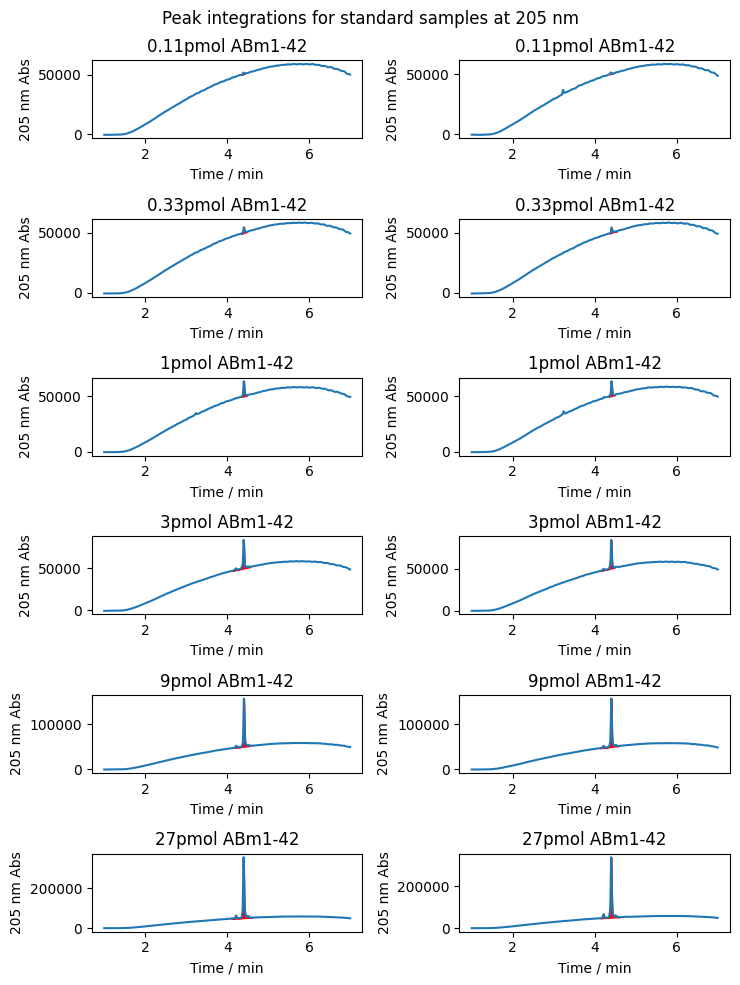

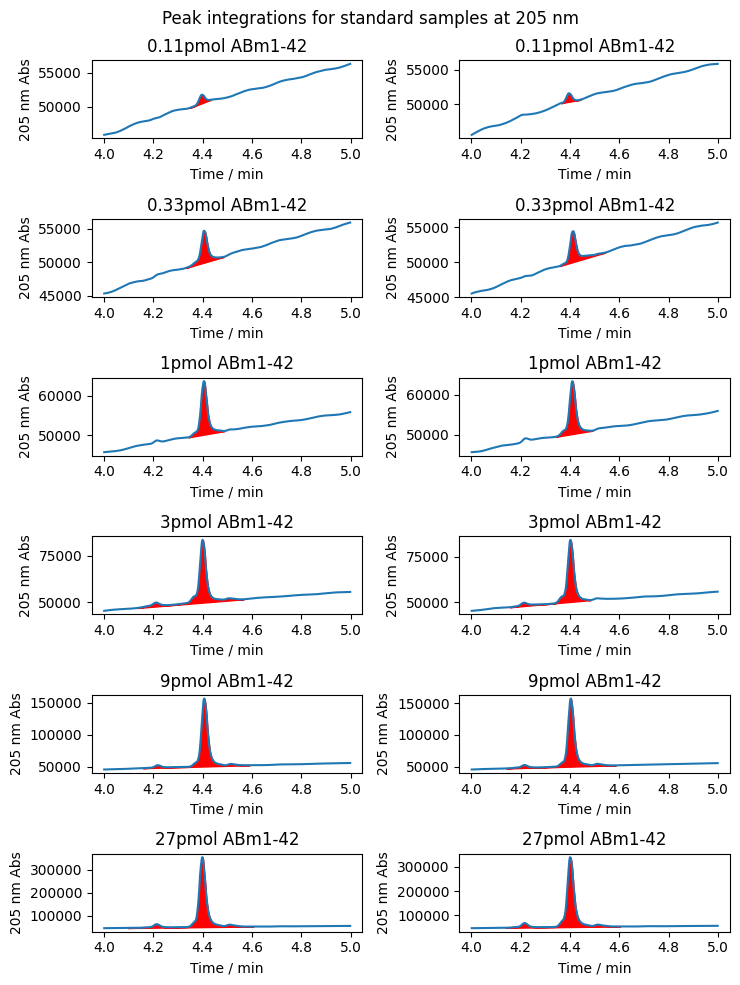

In [26]:

pos = [(i,j) for i in range(6) for j in range(2)]
#methods = ['UV','MS']
for zoom in [(1,7),(4,5)]:
    std_names=[]
    std_areas=[]
    fig, axs = plt.subplots(6,2,figsize=(7.5,10),sharey=False)
    #for n,df in enumerat([UV,MS]):
    summary=UV.filter(pl.col('Sample Type')=='Standard(Calc.Point)').sort(by='Std. Conc.')
    for i,name in enumerate(summary['Data Filename']):
        if summary.filter(pl.col('Data Filename')==name)['Peak Start'][0] != '-----':
    
            chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
            peak_start = float(summary.filter(pl.col('Data Filename')==name)['Peak Start'][0])
            peak_end = float(summary.filter(pl.col('Data Filename')==name)['Peak End'][0])
            df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            x=np.array([df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
            y=[df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][0],
               df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][-1]]
            slope, intercept = np.polyfit(x, y, 1)
            baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept
            
            axs[pos[i]].plot(df['Time (min)'],
                     df['Abs (µAu)'])
            poly_collect = axs[pos[i]].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                             df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'],
                            baseline,color='red')
            paths = poly_collect.get_paths()
            area = 0
            for path in paths:
                poly = Polygon(path.vertices)
                area += poly.area
            std_areas.append(area*60) # to get it in µAbs*s as in Labsolutions
            std_names.append(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_title(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_xlabel('Time / min')
            axs[pos[i]].set_ylabel('205 nm Abs')
        else:
            chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
            df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
           
            axs[pos[i]].plot(df['Time (min)'],
                     df['Abs (µAu)'])
            axs[pos[i]].set_title(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_xlabel('Time / min')
            axs[pos[i]].set_ylabel('205 nm Abs')
    plt.suptitle('Peak integrations for standard samples at 205 nm')
    plt.tight_layout()
    #plt.savefig('plots/260105 seeded temp sol/205nm integrations for samples at'+str(temp)+'degrees-original ints.pdf')

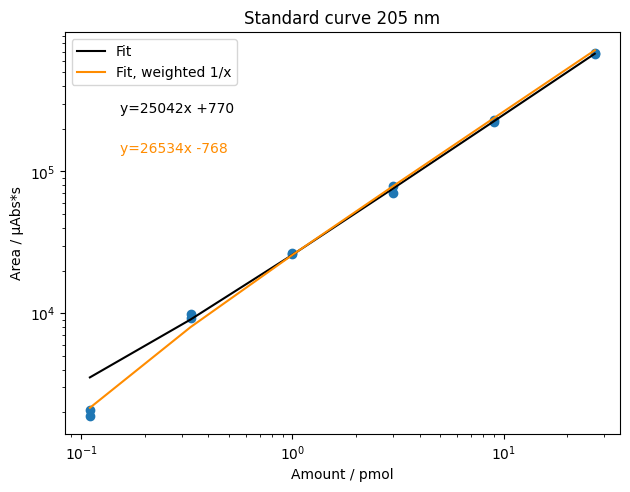

In [27]:

df= stds.sort(by='Std. Conc.')
std_curve = pl.DataFrame({
                'pmol':df['Std. Conc.'],
                'area':std_areas})
fit = np.polynomial.Polynomial.fit(std_curve['pmol'],std_curve['area'],deg=1).convert().coef
fit_w = np.polynomial.Polynomial.fit(std_curve['pmol'],std_curve['area'],deg=1,w=1/std_curve['pmol']).convert().coef
plt.scatter(std_curve['pmol'],std_curve['area'])
plt.plot(std_curve['pmol'],std_curve['pmol']*fit[1]+fit[0],label='Fit',c='black')
plt.plot(std_curve['pmol'],std_curve['pmol']*fit_w[1]+fit_w[0],label='Fit, weighted 1/x',c='darkorange')
plt.annotate('y='+str(round(fit[1]))+'x +'+str(round(fit[0])),
         (.1,.8),xycoords='axes fraction')
plt.annotate('y='+str(round(fit_w[1]))+'x '+str(round(fit_w[0])),
         (.1,.7),xycoords='axes fraction',c='darkorange')
plt.loglog()
plt.legend()
plt.xlabel('Amount / pmol')
plt.ylabel('Area / µAbs*s')
plt.tight_layout()
plt.title('Standard curve 205 nm')
std_curve_eq = fit_w

### Controls (no controls for this experiment)

### Samples

In [28]:
UV.with_columns(
    pl.col('Conc.')/pl.col('Inj. Volume')
).sort(by='Sample Name')

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""B2""","""0.11pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.11pmol ABm1-42_001_03.lcd""","""Standard(Calc.Point)""",4.397,2086.0,0.029333,1277.0,4.347,4.435,0.11
"""B2""","""0.11pmol ABm1-42""",3.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.11pmol ABm1-42_001_04.lcd""","""Standard(Calc.Point)""",4.395,1872.0,0.026333,1227.0,4.362,4.445,0.11
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.33pmol ABm1-42_001_05.lcd""","""Standard(Calc.Point)""",4.407,9840.0,0.043778,4726.0,4.33,4.488,0.33
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.33pmol ABm1-42_001_06.lcd""","""Standard(Calc.Point)""",4.412,9363.0,0.041667,4412.0,4.357,4.545,0.33
"""B2""","""1pmol ABm1-42""",27.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_1pmol ABm1-42_001_07.lcd""","""Standard(Calc.Point)""",4.405,26554.0,0.039,13510.0,4.343,4.49,1.0
"""B2""","""1pmol ABm1-42""",27.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_1pmol ABm1-42_001_08.lcd""","""Standard(Calc.Point)""",4.41,26119.0,0.03837,13193.0,4.34,4.492,1.0
"""C2""","""27pmol ABm1-42""",27.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_27pmol ABm1-42_001_13.lcd""","""Standard(Calc.Point)""",4.4,680512.0,0.994259,304193.0,4.095,4.607,27.0
"""C2""","""27pmol ABm1-42""",27.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_27pmol ABm1-42_001_14.lcd""","""Standard(Calc.Point)""",4.4,672593.0,0.982704,289481.0,4.137,4.605,27.0
"""C2""","""3pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_3pmol ABm1-42_001_09.lcd""","""Standard(Calc.Point)""",4.4,82947.0,1.092333,33894.0,4.135,4.567,3.0


In [29]:
UV.filter(pl.col('Sample Type')=="Unknown"
         ).sort(by='Sample Name')

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""C3""","""45deg AB42""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_45deg AB42_001_06.lcd""","""Unknown""",4.41,50111.0,1.982,20659.0,4.15,4.6,null
"""C4""","""45deg AB42""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_45deg AB42_001_09.lcd""","""Unknown""",4.412,26974.0,1.069,11288.0,4.15,4.6,null
"""C5""","""45deg AB42""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_45deg AB42_001_12.lcd""","""Unknown""",4.41,33901.0,1.343,13613.0,4.15,4.6,null
"""D3""","""50deg AB42""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_50deg AB42_001_07.lcd""","""Unknown""",4.41,85020.0,3.359,21286.0,4.15,4.6,null
"""D4""","""50deg AB42""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_50deg AB42_001_10.lcd""","""Unknown""",4.405,40222.0,1.592,16030.0,4.15,4.6,null
"""D5""","""50deg AB42""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_50deg AB42_001_13.lcd""","""Unknown""",4.415,41257.0,1.633,16242.0,4.15,4.6,null
"""E3""","""55deg AB42""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_55deg AB42_001_08.lcd""","""Unknown""",4.413,112697.0,4.45,28250.0,4.15,4.6,null
"""E4""","""55deg AB42""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_55deg AB42_001_11.lcd""","""Unknown""",4.4,59987.0,2.371,22639.0,4.15,4.6,null
"""E5""","""55deg AB42""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_55deg AB42_001_14.lcd""","""Unknown""",4.413,52640.0,2.082,19828.0,4.15,4.6,null


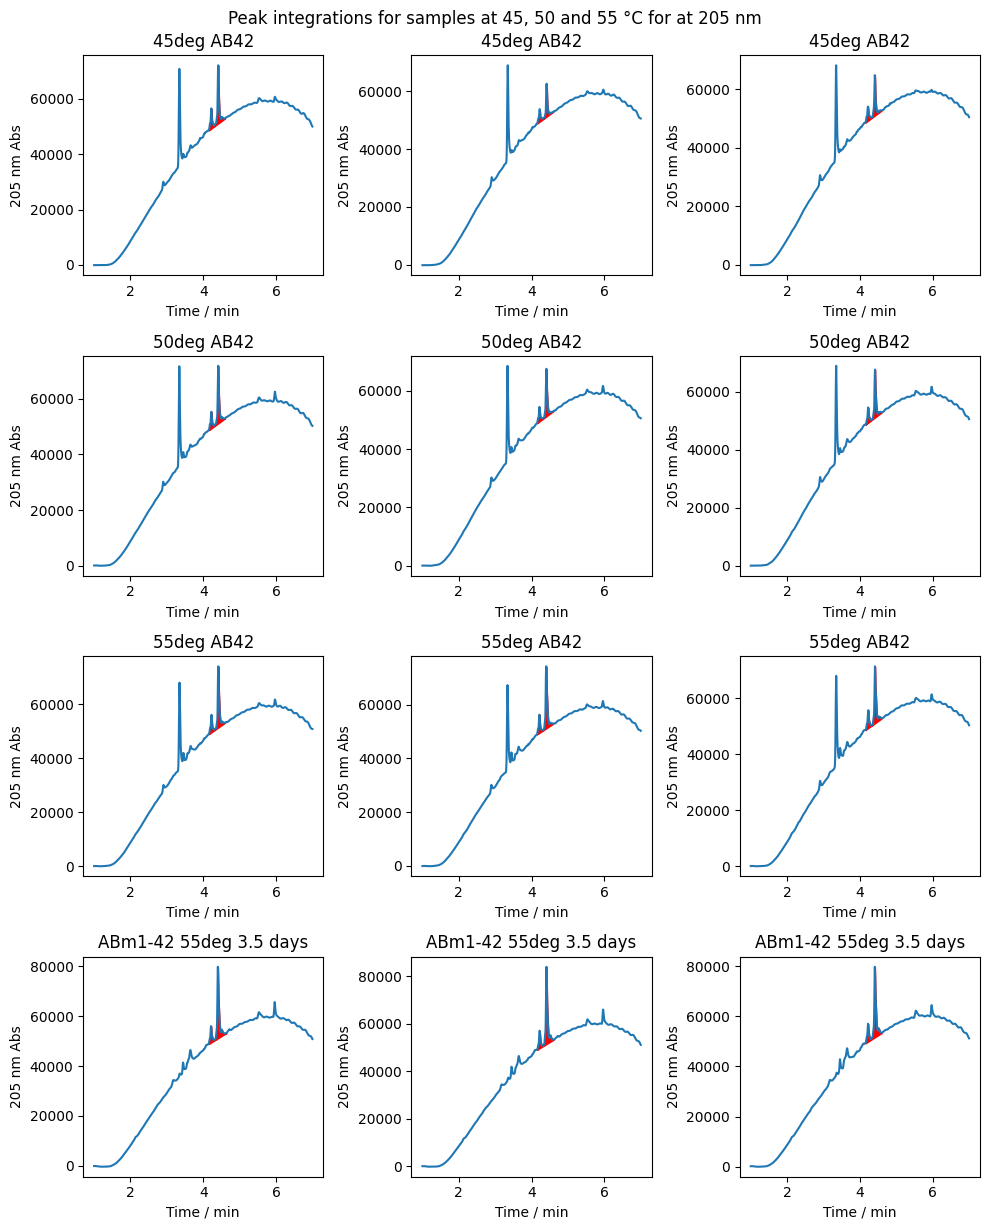

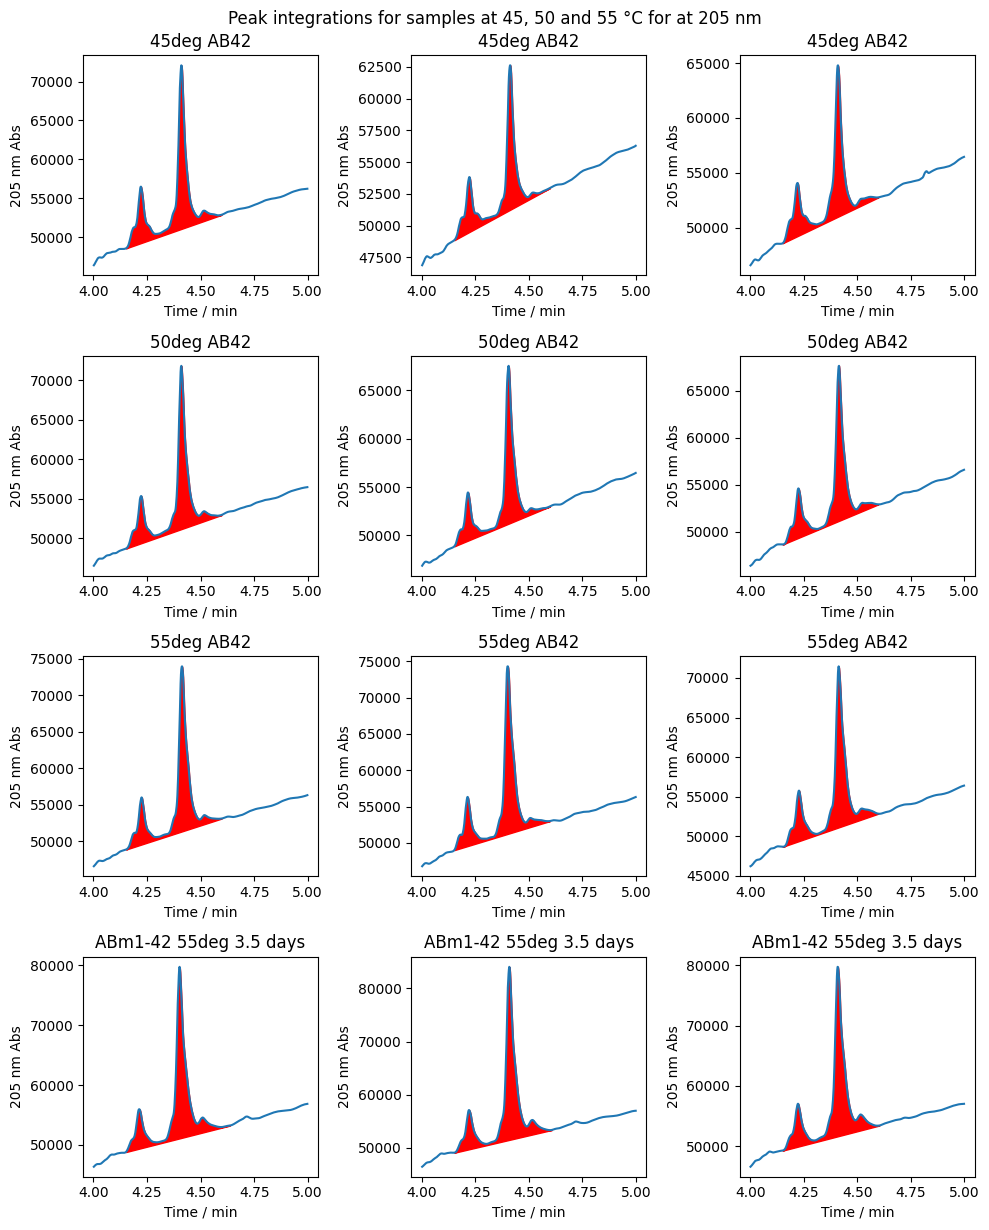

In [30]:
# time='65h'
# t1 = UV.filter(pl.col('Sample Type')=="Unknown"
#          ).filter(pl.col('Data Filename').str.contains(time))
pos = [(i,j) for i in range(4) for j in range(3)]

for zoom in [(1,7),(4,5)]:
    
    names=[]
    areas=[]
    inj_vols=[]

    #for temp in ['18','23','30','40','70']:
    #for time in ['65h','5days']:

    fig, axs = plt.subplots(4,3,figsize=(10,12.5),sharey=False)
    t_df = UV.filter(pl.col('Sample Type')=="Unknown"
         ).sort(by='Sample Name')
    
    for n,name in enumerate(t_df['Data Filename']):
        
        if t_df.filter(pl.col('Data Filename')==name)['Peak Start'][0]:
    
            chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
            peak_start = float(UV.filter(pl.col('Data Filename')==name)['Peak Start'][0])
            peak_end = float(UV.filter(pl.col('Data Filename')==name)['Peak End'][0])
            df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            x=np.array([df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
            y=[df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][0],
               df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][-1]]
            slope, intercept = np.polyfit(x, y, 1)
            baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept
            
            axs[pos[n]].plot(df['Time (min)'],
                     df['Abs (µAu)'])
            poly_collect = axs[pos[n]].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                             df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'],
                            baseline,color='red')
            paths = poly_collect.get_paths()
            area = 0
            for path in paths:
                poly = Polygon(path.vertices)
                area += poly.area
            areas.append(area*60) # to get it in µAbs*s as in Labsolutions
            names.append(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            inj_vols.append(UV.filter(pl.col('Data Filename')==name)['Inj. Volume'][0])
            axs[pos[n]].set_title(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[n]].set_xlabel('Time / min')
            axs[pos[n]].set_ylabel('205 nm Abs')
        else:
            chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
            df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            

            axs[pos[n]].plot(df['Time (min)'],
                     df['Abs (µAu)'])
            
        
            axs[pos[n]].set_title(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[n]].set_xlabel('Time / min')
            axs[pos[n]].set_ylabel('205 nm Abs')
    plt.suptitle('Peak integrations for samples at 45, 50 and 55 °C for at 205 nm')
    plt.tight_layout()
    plt.savefig('plots/'+project_name+'/205nm integrations for samples at 2-4 days-zoomed between '+str(zoom[0])+' and '+str(zoom[1])+'.pdf')


### Calc. Conc.

In [31]:
amounts_UV= pl.DataFrame({'Sample Name':names,
                           'Area (python)':areas,
                          'Inj. Vol.':inj_vols
                          # 'Amount (pmol)':[(areas-fit_w[0])/fit_w[1]]+[(control_areas-fit_w[0])/fit_w[1]], #amount (pmol) calculated from area and standard curve, divided by injection volume of 30 µl, times a 1000 to get nM
                            }).with_columns(
    ((pl.col('Area (python)')-fit_w[0])/fit_w[1]).alias('Amount (pmol)')
)
# conces_UV_man_int.with_columns(
#     (pl.col('Amount (pmol)')/pl.col('Inj. Vol.')*1000).alias('Conc. (nM)')
# )

In [32]:
amounts_UV

Sample Name,Area (python),Inj. Vol.,Amount (pmol)
str,f64,f64,f64
"""45deg AB42""",79899.49845,30.0,3.040143
"""45deg AB42""",42508.37535,30.0,1.630976
"""45deg AB42""",54232.5261,30.0,2.072826
"""50deg AB42""",76346.0802,30.0,2.906224
"""50deg AB42""",59306.2086,30.0,2.264039
"""50deg AB42""",62631.9891,30.0,2.389378
"""55deg AB42""",83903.00775,30.0,3.191024
"""55deg AB42""",88136.448,30.0,3.35057
"""55deg AB42""",82270.45065,30.0,3.129497


In [33]:
concs_UV=amounts_UV.with_columns(
    (pl.col('Amount (pmol)')/pl.col('Inj. Vol.')*1000).alias('Conc. (nM)')
)
concs_UV


Sample Name,Area (python),Inj. Vol.,Amount (pmol),Conc. (nM)
str,f64,f64,f64,f64
"""45deg AB42""",79899.49845,30.0,3.040143,101.338086
"""45deg AB42""",42508.37535,30.0,1.630976,54.365853
"""45deg AB42""",54232.5261,30.0,2.072826,69.094203
"""50deg AB42""",76346.0802,30.0,2.906224,96.874139
"""50deg AB42""",59306.2086,30.0,2.264039,75.467967
"""50deg AB42""",62631.9891,30.0,2.389378,79.645946
"""55deg AB42""",83903.00775,30.0,3.191024,106.367456
"""55deg AB42""",88136.448,30.0,3.35057,111.685674
"""55deg AB42""",82270.45065,30.0,3.129497,104.316572


In [34]:
# corr_factor = (10000/
# concs_UV.filter(pl.col('Sample Name')=="AB(M1-42)"
#                 ).mean()['Conc. (nM)'][0])
# corr_factor

In [35]:
# concs_UV=concs_UV.with_columns(
#     (pl.col('Conc. (nM)')*corr_factor).alias('Corr. Conc. (nM)')
# )

In [36]:
# concs_UV.filter(~pl.col('Sample Name').str.contains('buffer')
#                         ).filter(pl.col('Sample Name').str.contains('10uM')
#                             )['Corr. Conc. (nM)'].to_numpy()

In [37]:
concs_UV.filter(pl.col('Sample Name').str.contains('buffer'))
                                    

Sample Name,Area (python),Inj. Vol.,Amount (pmol),Conc. (nM)
str,f64,f64,f64,f64


In [38]:
concs_UV.filter(~pl.col('Sample Name').str.contains('buffer')
                        ).filter(pl.col('Sample Name').str.contains('55')
                            )

Sample Name,Area (python),Inj. Vol.,Amount (pmol),Conc. (nM)
str,f64,f64,f64,f64
"""55deg AB42""",83903.00775,30.0,3.191024,106.367456
"""55deg AB42""",88136.448,30.0,3.35057,111.685674
"""55deg AB42""",82270.45065,30.0,3.129497,104.316572
"""ABm1-42 55deg 3.5 days""",110762.968965,30.0,4.203301,140.11002
"""ABm1-42 55deg 3.5 days""",123148.907541,30.0,4.670092,155.669735
"""ABm1-42 55deg 3.5 days""",113708.620728,30.0,4.314314,143.810467


In [39]:
concs_UV['Sample Name'].unique()

Sample Name
str
"""ABm1-42 55deg 3.5 days"""
"""45deg AB42"""
"""50deg AB42"""
"""55deg AB42"""


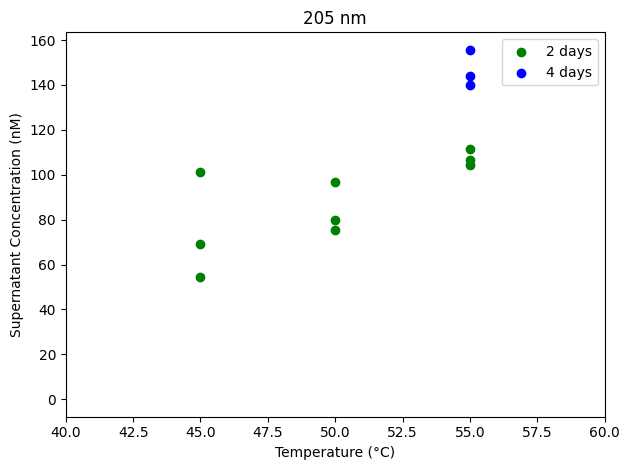

In [40]:
temps=['45','50','55']
t1=[]
t2=[]
temps_t1=[]
temps_t2=[]

for temp in temps:
    y_t1=concs_UV.filter(~pl.col('Sample Name').str.contains('3.5 days')
                        ).filter(pl.col('Sample Name').str.contains(temp)
                            )['Conc. (nM)']
           
    y_t1=y_t1.filter(y_t1>0).to_numpy()
    t1.append(y_t1)
    temps_t1.append([int(temp)]*len(y_t1))
    
    plt.scatter([int(temp)]*len(y_t1),y_t1,color='green')
    
plt.scatter([55]*3,concs_UV.filter(pl.col('Sample Name').str.contains('3.5 days')
                        )['Conc. (nM)'].to_numpy(),color='blue')
t2=concs_UV.filter(pl.col('Sample Name').str.contains('3.5 days')
                        )['Conc. (nM)'].to_list()

UV_values = pl.DataFrame({'Temp':temps_t1[0]+temps_t1[1]+temps_t1[2]+[55]*3,
                           'Conc (nM)':list(t1[0])+list(t1[1])+list(t1[2])+t2,
                           'Incubation time (days)':[2]*9+[4]*3})

plt.scatter(0,0,color='green',label='2 days')
plt.scatter(0,0,color='blue',label='4 days')
plt.xlim(40,60)
plt.legend()
plt.xlabel('Temperature (°C)')
plt.ylabel('Supernatant Concentration (nM)')
plt.title('205 nm')
plt.tight_layout()
plt.savefig('plots/'+project_name+'/205nm replicates.pdf')

In [41]:
pl.DataFrame({'Temp':temps_t1[0]+temps_t1[1]+temps_t1[2]+[55]*3,
                           'Conc (nM)':list(t1[0])+list(t1[1])+list(t1[2])+t2,
                           'Incubation time (days)':[2]*9+[4]*3})

Temp,Conc (nM),Incubation time (days)
i64,f64,i64
45,101.338086,2
45,54.365853,2
45,69.094203,2
50,96.874139,2
50,75.467967,2
50,79.645946,2
55,106.367456,2
55,111.685674,2
55,104.316572,2


In [42]:
UV_values

Temp,Conc (nM),Incubation time (days)
i64,f64,i64
45,101.338086,2
45,54.365853,2
45,69.094203,2
50,96.874139,2
50,75.467967,2
50,79.645946,2
55,106.367456,2
55,111.685674,2
55,104.316572,2


In [43]:
UV_values.write_csv('Processed data/'+project_name+'/UV values.csv')

## MS

### Standard curve

In [44]:
stds = MS.filter(pl.col('Sample Type')=='Standard(Calc.Point)').with_columns(
     pl.col('Std. Conc.').cast(pl.Float32),
     pl.col('Area').cast(pl.Float32),
     pl.col('Height').cast(pl.Float32)
)
stds

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f32,f64,f32,f64,f64,f32
"""B2""","""0.11pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.11pmol ABm1-42_001_03.lcd""","""Standard(Calc.Point)""",4.413,7391.0,0.073,2228.0,4.35,4.517,0.11
"""B2""","""0.11pmol ABm1-42""",3.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.11pmol ABm1-42_001_04.lcd""","""Standard(Calc.Point)""",4.411,7114.0,0.068,1993.0,4.35,4.567,0.11
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.33pmol ABm1-42_001_05.lcd""","""Standard(Calc.Point)""",4.423,21860.0,0.366,6440.0,4.367,4.567,0.33
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.33pmol ABm1-42_001_06.lcd""","""Standard(Calc.Point)""",4.426,21744.0,0.364,6361.0,4.333,4.567,0.33
"""B2""","""1pmol ABm1-42""",27.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_1pmol ABm1-42_001_07.lcd""","""Standard(Calc.Point)""",4.42,66732.0,1.274,19359.0,4.35,4.767,1.0
"""B2""","""1pmol ABm1-42""",27.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_1pmol ABm1-42_001_08.lcd""","""Standard(Calc.Point)""",4.426,60146.0,1.141,16968.0,4.35,4.583,1.0
"""C2""","""27pmol ABm1-42""",27.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_27pmol ABm1-42_001_13.lcd""","""Standard(Calc.Point)""",4.416,1.308549e6,26.4,369996.0,4.283,4.95,27.0
"""C2""","""27pmol ABm1-42""",27.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_27pmol ABm1-42_001_14.lcd""","""Standard(Calc.Point)""",4.417,1.288584e6,25.996,378560.0,4.35,4.967,27.0
"""C2""","""3pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_3pmol ABm1-42_001_09.lcd""","""Standard(Calc.Point)""",4.418,154879.0,3.057,44843.0,4.35,4.667,3.0


In [45]:
summaryMS

,Data Filename,Sample Type,Sample Name,Vial#,Ret. Time,Area,…,Accuracy[%],Cal. Point,Peak Start,Peak End,Quant. Limit(QL),S/N,Tailing F.
i64,str,str,str,str,f64,f64,…,f64,str,f64,f64,f64,f64,str
1,"""240428-std curve_0.11pmol ABm1-42_001_04.lcd""","""Standard(Calc.Point)""","""0.11pmol ABm1-42""","""B2""",4.411,7114.0,…,61.4,"""*""",4.35,4.567,0.49,1.38,"""1.603"""
2,"""240428-std curve_0.11pmol ABm1-42_001_03.lcd""","""Standard(Calc.Point)""","""0.11pmol ABm1-42""","""B2""",4.413,7391.0,…,66.5,"""*""",4.35,4.517,0.43,1.7,"""1.458"""
3,"""240428-std curve_0.33pmol ABm1-42_001_06.lcd""","""Standard(Calc.Point)""","""0.33pmol ABm1-42""","""B2""",4.426,21744.0,…,110.2,"""*""",4.333,4.567,0.96,3.8,"""1.373"""
4,"""240428-std curve_0.33pmol ABm1-42_001_05.lcd""","""Standard(Calc.Point)""","""0.33pmol ABm1-42""","""B2""",4.423,21860.0,…,110.9,"""*""",4.367,4.567,1.0,3.67,"""1.405"""
5,"""240428-std curve_1pmol ABm1-42_001_08.lcd""","""Standard(Calc.Point)""","""1pmol ABm1-42""","""B2""",4.426,60146.0,…,114.1,"""*""",4.35,4.583,1.31,8.72,"""1.506"""
6,"""240428-std curve_1pmol ABm1-42_001_07.lcd""","""Standard(Calc.Point)""","""1pmol ABm1-42""","""B2""",4.42,66732.0,…,127.4,"""*""",4.35,4.767,1.43,8.93,"""1.342"""
7,"""240428-std curve_3pmol ABm1-42_001_10.lcd""","""Standard(Calc.Point)""","""3pmol ABm1-42""","""C2""",4.419,154087.0,…,101.4,"""*""",4.35,4.717,0.67,45.17,"""1.451"""
8,"""240428-std curve_3pmol ABm1-42_001_09.lcd""","""Standard(Calc.Point)""","""3pmol ABm1-42""","""C2""",4.418,154879.0,…,101.9,"""*""",4.35,4.667,0.65,47.16,"""1.470"""
9,"""240428-std curve_9pmol ABm1-42_001_12.lcd""","""Standard(Calc.Point)""","""9pmol ABm1-42""","""C2""",4.419,467398.0,…,104.2,"""*""",4.333,4.917,0.96,97.53,"""1.441"""


In [46]:
data_MS['240428-std curve_27pmol ABm1-42_001_13.txt_MS-TIC']

Time (min),Absolute Intensity,Relative Intensity
f64,i64,f64
0.5,4331,1.15
0.517,4415,1.18
0.533,4437,1.18
0.55,4411,1.18
0.567,4409,1.18
0.583,4453,1.19
0.6,4596,1.23
0.617,4769,1.27
0.633,4744,1.27


In [47]:
MS

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_none_001_01.lcd""","""Control""",4.4,1794.0,-0.04,150.0,4.2,4.433,null
"""-1""","""none""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_none_001_16.lcd""","""Control""",null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240502 solABm1-42 t2 55deg_none_001_01.lcd""","""Control""",4.303,1951.0,-0.037,206.0,4.267,4.567,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240502 solABm1-42 t2 55deg_none_005_05.lcd""","""Control""",4.413,2491.0,-0.026,515.0,4.25,4.467,null
"""A3""","""buffer""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_buffer_001_02.lcd""","""Control""",null,null,null,null,null,null,null
"""A4""","""buffer""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240430 solABm1-42_buffer_001_15.lcd""","""Control""",4.383,2184.0,-0.032,127.0,4.35,4.717,null
"""B2""","""0.11pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.11pmol ABm1-42_001_03.lcd""","""Standard(Calc.Point)""",4.413,7391.0,0.073,2228.0,4.35,4.517,0.11
"""B2""","""0.11pmol ABm1-42""",3.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.11pmol ABm1-42_001_04.lcd""","""Standard(Calc.Point)""",4.411,7114.0,0.068,1993.0,4.35,4.567,0.11
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.33pmol ABm1-42_001_05.lcd""","""Standard(Calc.Point)""",4.423,21860.0,0.366,6440.0,4.367,4.567,0.33


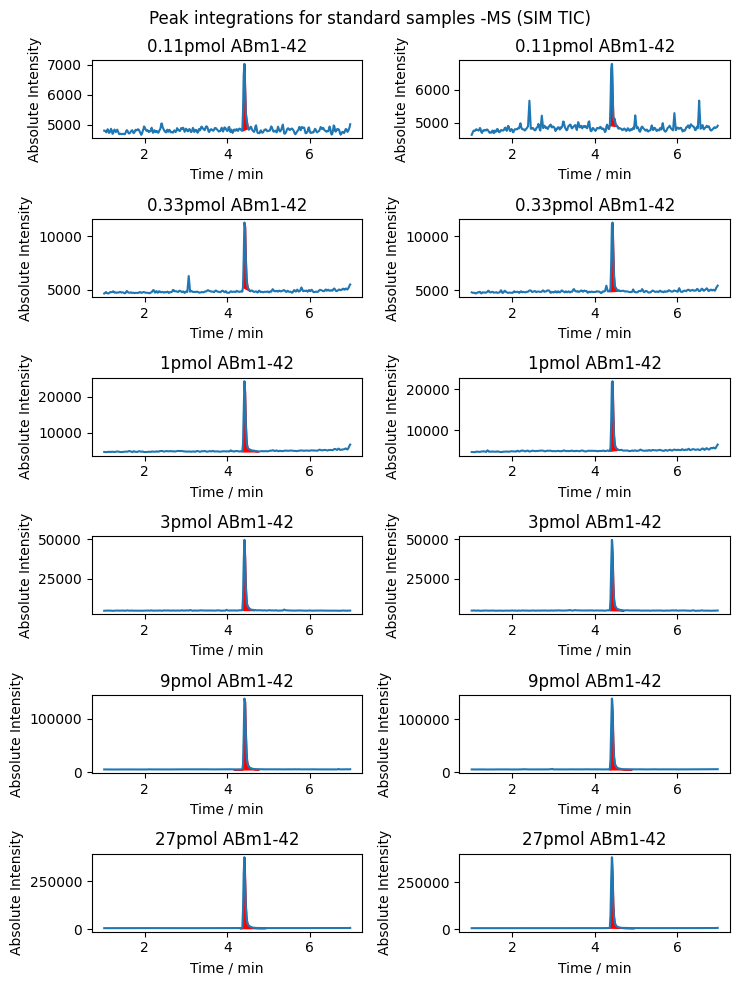

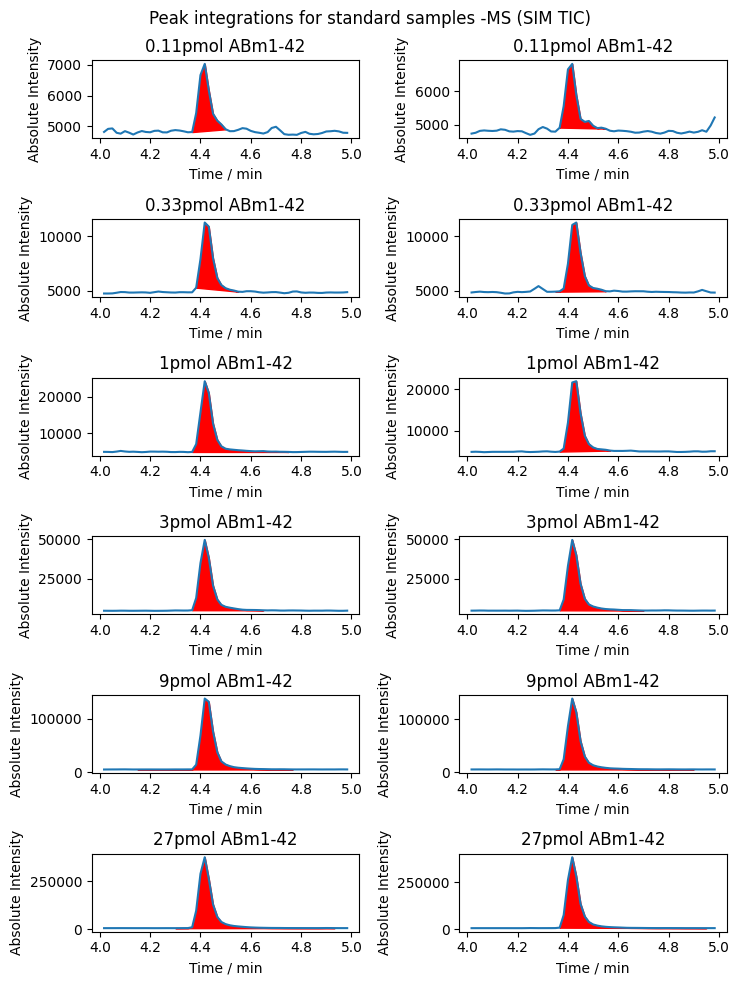

In [48]:

pos = [(i,j) for i in range(6) for j in range(2)]
#methods = ['UV','MS']
for zoom in [(1,7),(4,5)]:
    std_names=[]
    std_areas=[]
    fig, axs = plt.subplots(6,2,figsize=(7.5,10),sharey=False)
    #for n,df in enumerat([UV,MS]):
    summary=MS.filter(pl.col('Sample Type')=='Standard(Calc.Point)').sort(by='Std. Conc.')
    for i,name in enumerate(summary['Data Filename']):
        if summary.filter(pl.col('Data Filename')==name)['Peak Start'][0] != '-----':
    
            chrom_name = name.split('.lcd')[0]+'.txt'+'_MS-TIC'
            peak_start = float(summary.filter(pl.col('Data Filename')==name)['Peak Start'][0])
            peak_end = float(summary.filter(pl.col('Data Filename')==name)['Peak End'][0])
            df=data_MS[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            x=np.array([df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
            y=[df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'][0],
               df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'][-1]]
            slope, intercept = np.polyfit(x, y, 1)
            baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept
            
            axs[pos[i]].plot(df['Time (min)'],
                     df['Absolute Intensity'])
            poly_collect = axs[pos[i]].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                             df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'],
                            baseline,color='red')
            paths = poly_collect.get_paths()
            area = 0
            for path in paths:
                poly = Polygon(path.vertices)
                area += poly.area
            std_areas.append(area*60) # to get it in A.U.*s as in Labsolutions?
            std_names.append(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_title(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_xlabel('Time / min')
            axs[pos[i]].set_ylabel('Absolute Intensity')
        else:
            chrom_name = name.split('.lcd')[0]+'.txt'+'_MS-TIC'
            df=data_MS[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
           
            axs[pos[i]].plot(df['Time (min)'],
                     df['Absolute Intensity'])
            axs[pos[i]].set_title(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_xlabel('Time / min')
            axs[pos[i]].set_ylabel('Absolute Intensity')
    plt.suptitle('Peak integrations for standard samples -MS (SIM TIC)')
    plt.tight_layout()
    #plt.savefig('plots/260105 seeded temp sol/205nm integrations for samples at'+str(temp)+'degrees-original ints.pdf')

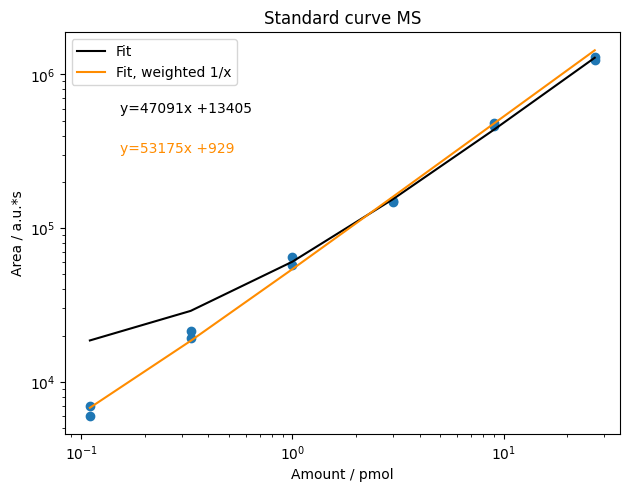

In [49]:

df= stds.sort(by='Std. Conc.')
std_curve = pl.DataFrame({
                'pmol':df['Std. Conc.'],
                'area':std_areas})
fit = np.polynomial.Polynomial.fit(std_curve['pmol'],std_curve['area'],deg=1).convert().coef
fit_w = np.polynomial.Polynomial.fit(std_curve['pmol'],std_curve['area'],deg=1,w=1/std_curve['pmol']).convert().coef
plt.scatter(std_curve['pmol'],std_curve['area'])
plt.plot(std_curve['pmol'],std_curve['pmol']*fit[1]+fit[0],label='Fit',c='black')
plt.plot(std_curve['pmol'],std_curve['pmol']*fit_w[1]+fit_w[0],label='Fit, weighted 1/x',c='darkorange')
plt.annotate('y='+str(round(fit[1]))+'x +'+str(round(fit[0])),
         (.1,.8),xycoords='axes fraction')
plt.annotate('y='+str(round(fit_w[1]))+'x +'+str(round(fit_w[0])),
         (.1,.7),xycoords='axes fraction',c='darkorange')
plt.loglog()
plt.legend()
plt.xlabel('Amount / pmol')
plt.ylabel('Area / a.u.*s')
plt.tight_layout()
plt.title('Standard curve MS')
std_curve_eq = fit_w

### Controls (no controls in this exp)

### Samples

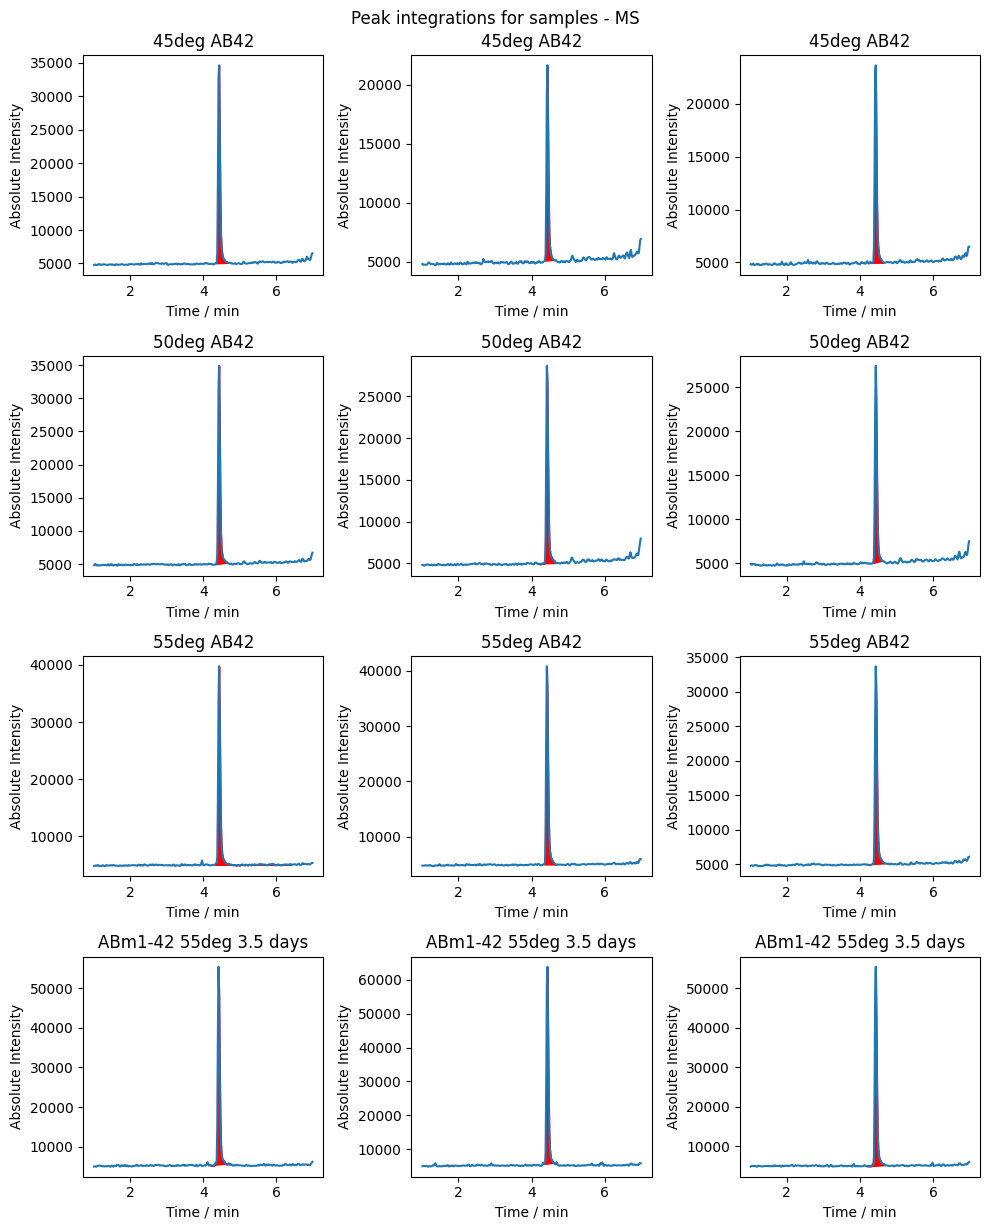

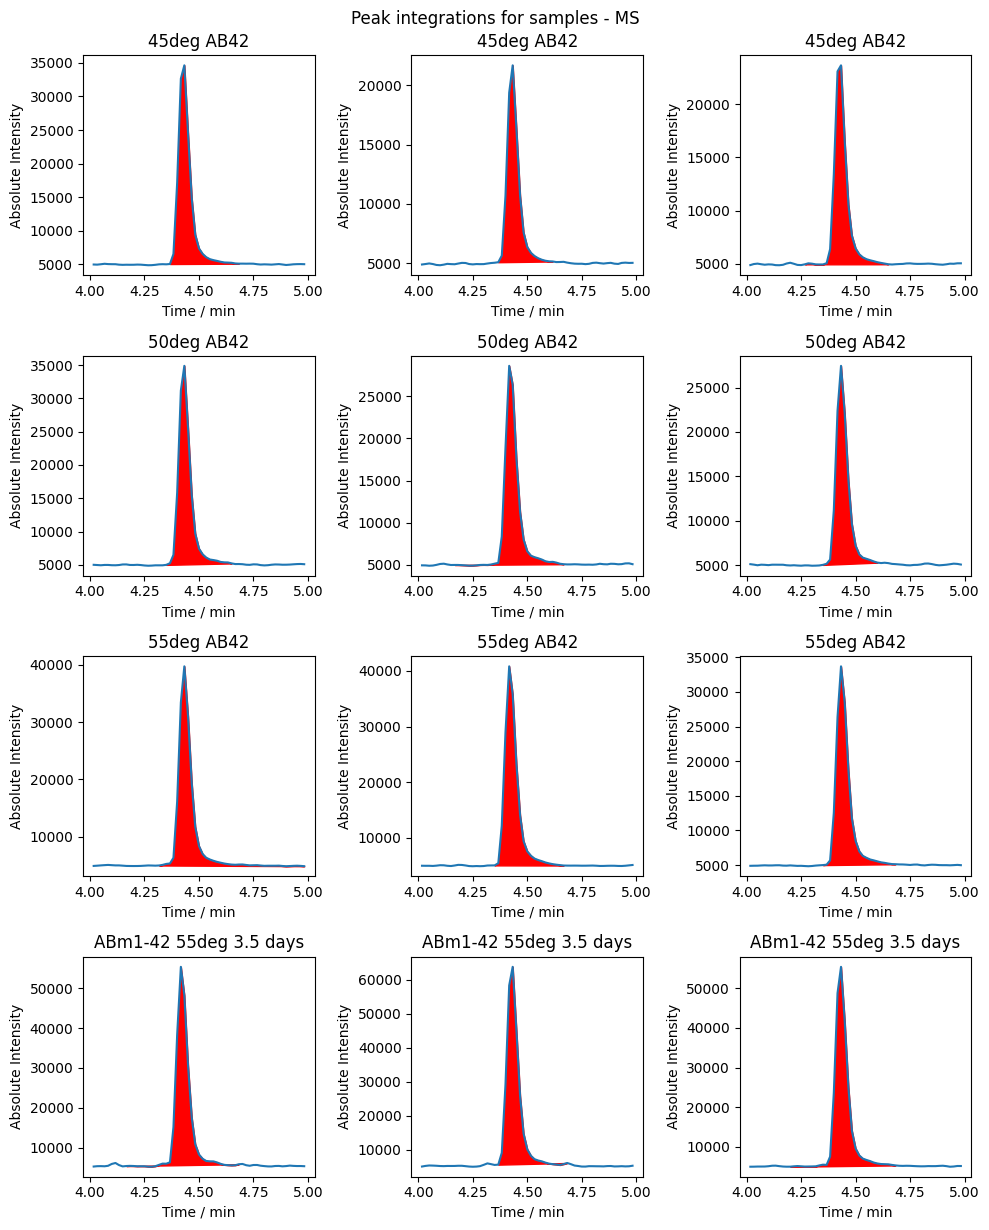

In [50]:
# time='65h'
# t1 = UV.filter(pl.col('Sample Type')=="Unknown"
#          ).filter(pl.col('Data Filename').str.contains(time))
pos = [(i,j) for i in range(4) for j in range(3)]


for zoom in [(1,7),(4,5)]:
    
    names=[]
    areas=[]
    inj_vols=[]

    #for temp in ['18','23','30','40','70']:
    #for time in ['65h','5days']:

    fig, axs = plt.subplots(4,3,figsize=(10,12.5),sharey=False)
    t_df = MS.filter(pl.col('Sample Type')=="Unknown"
     ).sort(by='Sample Name')
    
    for n,name in enumerate(t_df['Data Filename']):
        
        if t_df.filter(pl.col('Data Filename')==name)['Peak Start'][0]:
    
            chrom_name = name.split('.lcd')[0]+'.txt'+'_MS-TIC'
            peak_start = float(MS.filter(pl.col('Data Filename')==name)['Peak Start'][0])
            peak_end = float(MS.filter(pl.col('Data Filename')==name)['Peak End'][0])
            df=data_MS[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            x=np.array([df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
            y=[df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'][0],
               df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'][-1]]
            slope, intercept = np.polyfit(x, y, 1)
            baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept

            axs[pos[n]].plot(df['Time (min)'],
                     df['Absolute Intensity'])
            poly_collect = axs[pos[n]].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                             df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'],
                            baseline,color='red')
            paths = poly_collect.get_paths()
            area = 0
            for path in paths:
                poly = Polygon(path.vertices)
                area += poly.area
            areas.append(area*60) # to get it in A.U.*s 
            names.append(MS.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            inj_vols.append(MS.filter(pl.col('Data Filename')==name)['Inj. Volume'][0])
            axs[pos[n]].set_title(MS.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[n]].set_xlabel('Time / min')
            axs[pos[n]].set_ylabel('Absolute Intensity')
        else:
            chrom_name = name.split('.lcd')[0]+'.txt'+'_MS-TIC'
            df=data_MS[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
           

            axs[pos[n]].plot(df['Time (min)'],
                     df['Absolute Intensity'])
           
            
            axs[pos[n]].set_title(MS.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[n]].set_xlabel('Time / min')
            axs[pos[n]].set_ylabel('Absolute Intensity')
    plt.suptitle('Peak integrations for samples - MS')
    plt.tight_layout()
    plt.savefig('plots/'+project_name+'/MS integrations for samples -zoomed between '+str(zoom[0])+' and '+str(zoom[1])+'.pdf')


### Calc. Conc.

In [51]:
amounts_MS= pl.DataFrame({'Sample Name':names,
                           'Area (python)':areas,
                          'Inj. Vol.':inj_vols
                          # 'Amount (pmol)':[(areas-fit_w[0])/fit_w[1]]+[(control_areas-fit_w[0])/fit_w[1]], #amount (pmol) calculated from area and standard curve, divided by injection volume of 30 µl, times a 1000 to get nM
                            }).with_columns(
    ((pl.col('Area (python)')-fit_w[0])/fit_w[1]).alias('Amount (pmol)')
)
# conces_MS_man_int.with_columns(
#     (pl.col('Amount (pmol)')/pl.col('Inj. Vol.')*1000).alias('Conc. (nM)')
# )

In [52]:
amounts_MS

Sample Name,Area (python),Inj. Vol.,Amount (pmol)
str,f64,f64,f64
"""45deg AB42""",111478.722,30.0,2.078987
"""45deg AB42""",59147.73,30.0,1.094857
"""45deg AB42""",71249.22606,30.0,1.322436
"""50deg AB42""",110802.69,30.0,2.066273
"""50deg AB42""",89837.22,30.0,1.671999
"""50deg AB42""",81774.705,30.0,1.520377
"""55deg AB42""",136311.672,30.0,2.545992
"""55deg AB42""",138549.03024,30.0,2.588068
"""55deg AB42""",111969.12474,30.0,2.088209


In [53]:
concs_MS=amounts_MS.with_columns(
    (pl.col('Amount (pmol)')/pl.col('Inj. Vol.')*1000).alias('Conc. (nM)')
)
concs_MS#.filter(pl.col('Sample Name').str.contains('40')
                             #   )

Sample Name,Area (python),Inj. Vol.,Amount (pmol),Conc. (nM)
str,f64,f64,f64,f64
"""45deg AB42""",111478.722,30.0,2.078987,69.29956
"""45deg AB42""",59147.73,30.0,1.094857,36.495225
"""45deg AB42""",71249.22606,30.0,1.322436,44.081199
"""50deg AB42""",110802.69,30.0,2.066273,68.875781
"""50deg AB42""",89837.22,30.0,1.671999,55.733315
"""50deg AB42""",81774.705,30.0,1.520377,50.679226
"""55deg AB42""",136311.672,30.0,2.545992,84.866405
"""55deg AB42""",138549.03024,30.0,2.588068,86.268921
"""55deg AB42""",111969.12474,30.0,2.088209,69.606975


In [54]:
# corr_factor = (10000/
# concs_MS.filter(pl.col('Sample Name')=="AB(M1-42)"
#                 )['Conc. (nM)'][0])
# corr_factor

In [55]:
# concs_MS=concs_MS.with_columns(
#     (pl.col('Conc. (nM)')*corr_factor).alias('Corr. Conc. (nM)')
# )

In [56]:
# concs_MS.filter(~pl.col('Sample Name').str.contains('buffer')
#                         ).filter(pl.col('Sample Name').str.contains('70')
#                             ).filter(pl.col('Sample Name').str.contains('10uM'))['Corr. Conc. (nM)'].to_numpy()

In [57]:
# concs_MS.filter(pl.col('Sample Name').str.contains('buffer'))
                                    

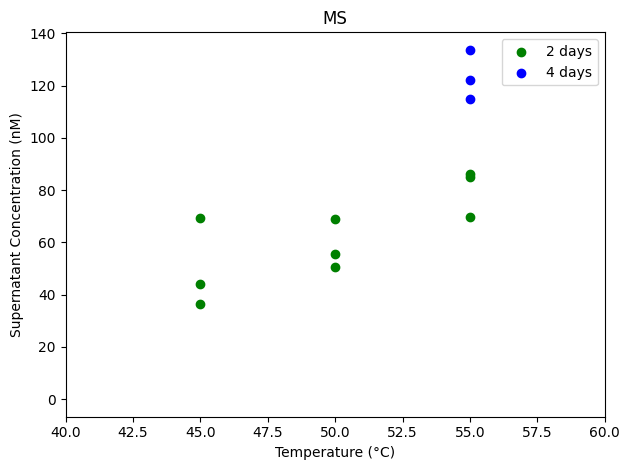

In [58]:
temps=['45','50','55']
t1=[]
#buffer_corr_t2=[]
temps_t1=[]
#temps_t2=[]

for temp in temps:
    y_t1=concs_MS.filter(~pl.col('Sample Name').str.contains('3.5 days')
                        ).filter(pl.col('Sample Name').str.contains(temp)
                            )['Conc. (nM)']
    y_t1=y_t1.filter(y_t1>0).to_numpy()
    t1.append(y_t1)
    temps_t1.append([int(temp)]*len(y_t1))
    
    plt.scatter([int(temp)]*len(y_t1),y_t1,color='green')
    
    
plt.scatter([55]*3,concs_MS.filter(pl.col('Sample Name').str.contains('3.5 days')
                        )['Conc. (nM)'].to_numpy(),color='blue')
t2=concs_MS.filter(pl.col('Sample Name').str.contains('3.5 days')
                        )['Conc. (nM)'].to_list()

values = pl.DataFrame({'Temp':temps_t1[0]+temps_t1[1]+temps_t1[2]+[55]*3,
                           'Conc (nM)':list(t1[0])+list(t1[1])+list(t1[2])+t2,
                           'Incubation time (days)':[2]*9+[4]*3})

plt.scatter(0,0,color='green',label='2 days')
plt.scatter(0,0,color='blue',label='4 days')
plt.xlim(40,60)
plt.legend()
plt.xlabel('Temperature (°C)')
plt.ylabel('Supernatant Concentration (nM)')
plt.title('MS')
plt.tight_layout()
plt.savefig('plots/'+project_name+'/MS replicates.pdf')

In [59]:
values

Temp,Conc (nM),Incubation time (days)
i64,f64,i64
45,69.29956,2
45,36.495225,2
45,44.081199,2
50,68.875781,2
50,55.733315,2
50,50.679226,2
55,84.866405,2
55,86.268921,2
55,69.606975,2


In [60]:
values.write_csv('Processed data/'+project_name+'/MS values.csv')